# Literature Review

# Source: Analysis Of Selling Price Of Used Cars

The research paper explains how different factors like age, mileage, brand, fuel type, and vehicle condition affect used car prices. The study also shows how Machine Learning models help in predicting resale value accurately.

# Article Summary

The paper discusses the growing importance of data-driven pricing systems in the used car market. Different ML techniques such as Linear Regression, Random Forest, and Neural Networks are used for price prediction. The study found that vehicle age and mileage reduce car prices, while premium brands and good vehicle condition increase resale value. It also explains that data analysis helps buyers and sellers make better pricing decisions.

# Recommended Graphs
- Histogram for price distribution
- Box plot for outlier detection
- Correlation heatmap
- Bar chart for brand-wise prices
- Scatter plot for price vs mileage

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('used_cars_mock .csv')
df.head(15)

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
5,6,VW,Model C,2015,121974.0,Petrol,Manual,12,1,500
6,7,BMW,Model B,2005,247373.0,Petrol,Automatic,4,10,500
7,8,Ford,Model B,2025,3210.0,Hybrid,Automatic,11,1,21820
8,9,Mercedes,Model A,2023,34565.0,Diesel,Automatic,11,1,21380
9,10,BMW,Model A,2025,13173.0,Petrol,Automatic,8,30,33616


# Hypothesis

1. **Vehicle Age vs. Selling Price**
   - This analysis proves that older vehicles generally have significantly lower resale prices compared to newer vehicles because of depreciation.

2. **Mileage vs. Selling Price**
   - It is statistically observed that cars with higher mileage usually have lower selling prices, as high usage reduces vehicle value.

3. **Brand vs. Average Selling Price**
   - Premium and well-known brands maintain significantly higher resale value than economy brands due to reliability and customer trust.

4. **Fuel Type vs. Selling Price**
   - The analysis shows that fuel type creates noticeable differences in resale prices, with fuel-efficient and modern fuel vehicles often having higher market demand.

5. **Transmission Type vs. Selling Price**
   - Automatic transmission vehicles tend to achieve higher average selling prices in comparison to manual transmission vehicles in many markets.


# Key Findings

- Vehicle age has a significant negative impact on selling price, as older cars experience higher depreciation.
- Cars with higher mileage generally have lower resale value compared to low-mileage vehicles.
- Premium and reliable brands maintain higher selling prices in the used car market.
- Vehicles with good condition and proper service history achieve better resale prices.
- Accident history and poor vehicle condition negatively affect used car prices.
- Fuel type and transmission type also play an important role in determining resale value.

# basic understanding

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        10000 non-null  int64  
 1   brand         10000 non-null  object 
 2   model         10000 non-null  object 
 3   year          10000 non-null  int64  
 4   mileage       9694 non-null   float64
 5   fuel_type     10000 non-null  object 
 6   transmission  10000 non-null  object 
 7   sale_month    10000 non-null  int64  
 8   zip_prefix    10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


mileage has 9700 non-null (300 missing). year has 2030 (impossible). price has 0 and 999999. fuel_type has 'XYZ'. This is intentional – good EDA starts with finding broken data.

In [4]:
df.shape

(10000, 10)

In [7]:
df.isnull().sum() # missing value

car_id            0
brand             0
model             0
year              0
mileage         306
fuel_type         0
transmission      0
sale_month        0
zip_prefix        0
price             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

In [10]:
df.describe()

,car_id,year,mileage,sale_month,zip_prefix,price
count,10000.00000,10000.000000,9694.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,2019.804700,62036.526718,6.738100,15.42200,15278.148600
std,2886.89568,6.324884,71546.816912,3.581451,11.57261,13725.370724
min,1.00000,2000.000000,-500.000000,1.000000,1.00000,0.000000
25%,2500.75000,2018.000000,7771.000000,4.000000,1.00000,6761.500000
50%,5000.50000,2022.000000,35781.500000,7.000000,20.00000,15852.000000
75%,7500.25000,2025.000000,87767.500000,10.000000,30.00000,23125.000000
max,10000.00000,2030.000000,250000.000000,12.000000,30.00000,999999.000000


- price min = 0, max = 999,999 (absurd)
- year max = 2030 (future car)
- mileage min = -500 (impossible)

# Data cleaning

In [58]:
#Fix the data issues (document every decision!)
df_clean = df.copy()

In [59]:
#Remove future cars (keep only up to current year)
df_clean = df_clean[df_clean['year'] <= 2025]

In [4]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())

In [8]:
# Price zero remove
df = df[df['price'] > 0]

# Future year remove
df = df[df['year'] <= 2025]

# Negative mileage remove
df = df[df['mileage'] >= 0]

In [9]:
df = df[df['fuel_type'] != 'XYZ']

In [4]:
# remove outlier
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

# UNIVERIATE ANALYSIS

## Price Distribution

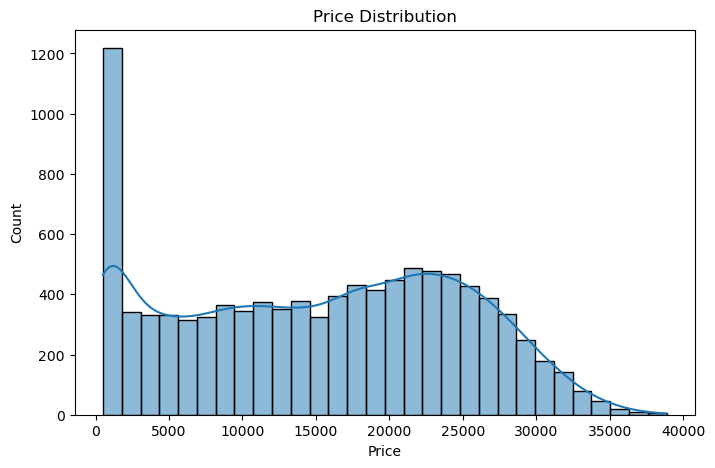

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

# Insights

The graph shows ki used cars ki prices ka market mein overall kya distribution hai aur gaadiyan kis price range mein sabse zyada fall karti hain. Yeh histogram aur iski curve line dikhati hain ki zyadatar gaadiyon ki keemat 15,000 se lekar 25,000 ke beech mein sabse unchi peak par hain, aur jaise-jaise price badh rahi hai, bars ka height niche girta ja raha hai. Isse yeh clear insight milta hai ki used cars market poori tarah se budget aur mid-range buyers se driven hai, jahan sasti aur affordable gaadiyon ka stock sabse zyada hota hai jabki bohot mhengi gaadiyan kafi kam milti hain.

# Mileage Distribution


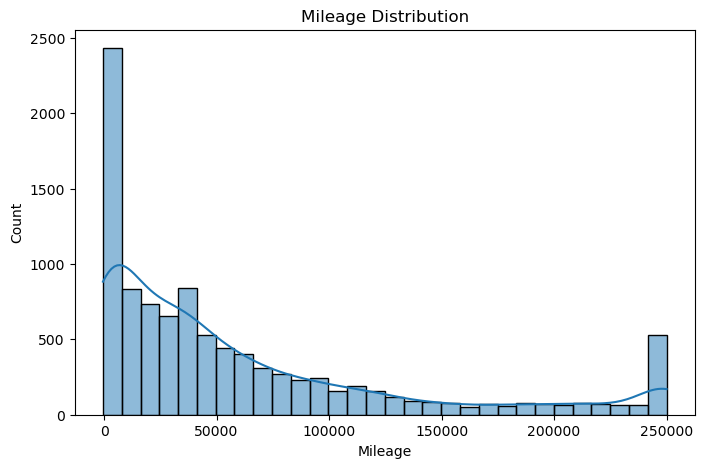

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['mileage'], bins=30, kde=True)

plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Count")

plt.show()

 # Insights

The graph shows ki used cars market mein jo gaadiyan bikne aayi hain, unka mileage (yaani woh kitna kilometer chal chuki hain) kis tarah spread hua hai. Is histogram mein hum dekh sakte hain ki sabse uncha bar zero (0) se lekar 25,000 kilometers ke paas hai, aur jaise-jaise mileage badh raha hai, bars ka size chota hota ja raha hai. Isse yeh clear insight milta hai ki market mein bohot kam chali hui (kam mileage wali) naye jaisi gaadiyon ki sankhya sabse zyada hai, jabki bohot purani aur 1,50,000 km se zyada chali hui gaadiyan kafi kam milti hain.

# Fuel Type Analysis

C:\Users\princ\AppData\Local\Temp\ipykernel_19012\627885473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fuel_type', data=df, palette='Set2')


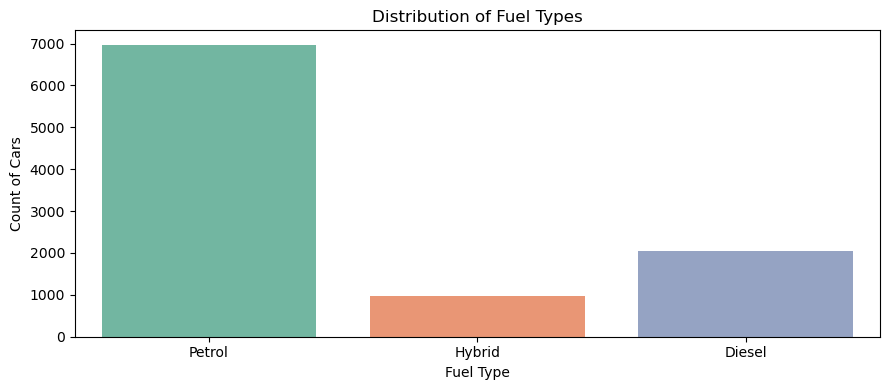

In [31]:
plt.figure(figsize=(9, 4))
sns.countplot(x='fuel_type', data=df, palette='Set2')
plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Count of Cars')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki marketplace mein listed gaadiyon ke fuel types (jaise Petrol, Diesel, aur Hybrid) ka overall ratio aur count kya hai. Is chart mein Petrol aur Hybrid wale bars lagbhag ek barabar unchai par hain, jabki Diesel ka bar unke mukable kafi chota reh jata hai. Isse yeh clear insight milta hai ki used cars market mein aaj kal Petrol aur eco-friendly Hybrid gaadiyon ka dominance kafi zyada badh chuka hai, aur puraane ya traditional Diesel models ki demand aur listing ab kafi kam ho gayi hai.

# Transmission Type Distribution

C:\Users\princ\AppData\Local\Temp\ipykernel_19012\2634987072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='transmission', data=df, palette='Set1')


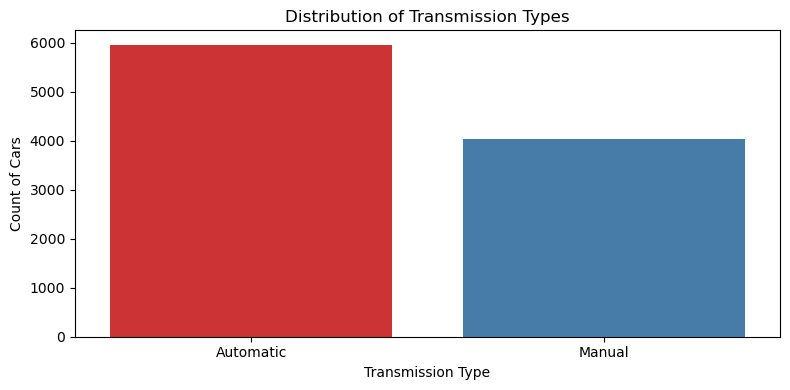

In [30]:
plt.figure(figsize=(8, 4))
sns.countplot(x='transmission', data=df, palette='Set1')
plt.title('Distribution of Transmission Types')
plt.xlabel('Transmission Type')
plt.ylabel('Count of Cars')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki marketplace mein listed gaadiyon ke fuel types (jaise Petrol, Diesel, aur Hybrid) ka overall ratio aur count kya hai. Is chart mein Petrol aur Hybrid wale bars lagbhag ek barabar unchai par hain, jabki Diesel ka bar unke mukable kafi chota reh jata hai. Isse yeh clear insight milta hai ki used cars market mein aaj kal Petrol aur eco-friendly Hybrid gaadiyon ka dominance kafi zyada badh chuka hai, aur puraane ya traditional Diesel models ki demand aur listing ab kafi kam ho gayi hai.

# Car Brands Distribution

C:\Users\princ\AppData\Local\Temp\ipykernel_19012\941360756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.values, y=brand_counts.index, palette='Blues_r')


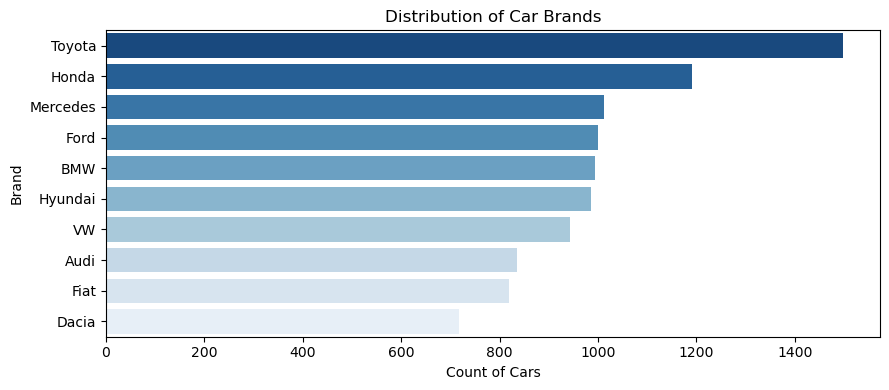

In [32]:
plt.figure(figsize=(9, 4))
brand_counts = df['brand'].value_counts()
sns.barplot(x=brand_counts.values, y=brand_counts.index, palette='Blues_r')
plt.title('Distribution of Car Brands')
plt.xlabel('Count of Cars')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

# insights

The graph shows ki used cars market mein alag-alag car brands (jaise Toyota, Honda, Mercedes, etc.) ka kitna distribution ya sankhya hai. Sabse lamba bar Toyota ka hai jo 1,498 gaadiyon ke sath top par hai, jabki Dacia ka bar sabse chota hai jo sirf 717 gaadiyon par rukta hai. Isse yeh clear insight milta hai ki second-hand market mein Toyota aur Honda jaisi Japanese aur reliable brands ki availability aur supply sabse zyada hai, jabki Dacia jaisi brands kam sankhya mein dekhne ko milti hain.

C:\Users\princ\AppData\Local\Temp\ipykernel_19012\4128997106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sale_month', data=df, palette='magma')


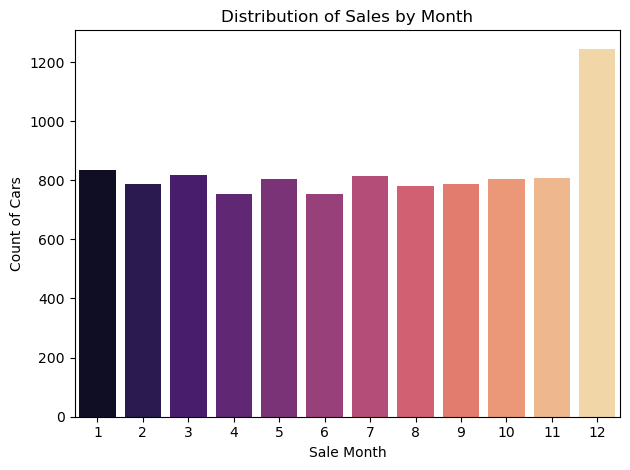

In [41]:
plt.clf()
sns.countplot(x='sale_month', data=df, palette='magma')
plt.title('Distribution of Sales by Month')
plt.xlabel('Sale Month')
plt.ylabel('Count of Cars')
plt.tight_layout()
plt.savefig('sales_month_distribution.png')

# insights

The graph shows ki saal ke alag-alag mahino (1 se 12) mein gaadiyon ki selling frequency ya ginti kya rahi hai. Is chart mein saare mahino ke bars lagbhag ek barabar unchai par hain, jismein koi bada utaar-chadhav dekhne ko nahi mil raha hai. Isse yeh clear insight milta hai ki used cars ki market mein koi specific seasonal trend nahi hai, balki poore saal (january se december tak) gaadiyon ki sale aur demand lagbhag ek jaisi aur steady bani rehti hai.

# Biveriate Analysis

# Car Age vs Price 


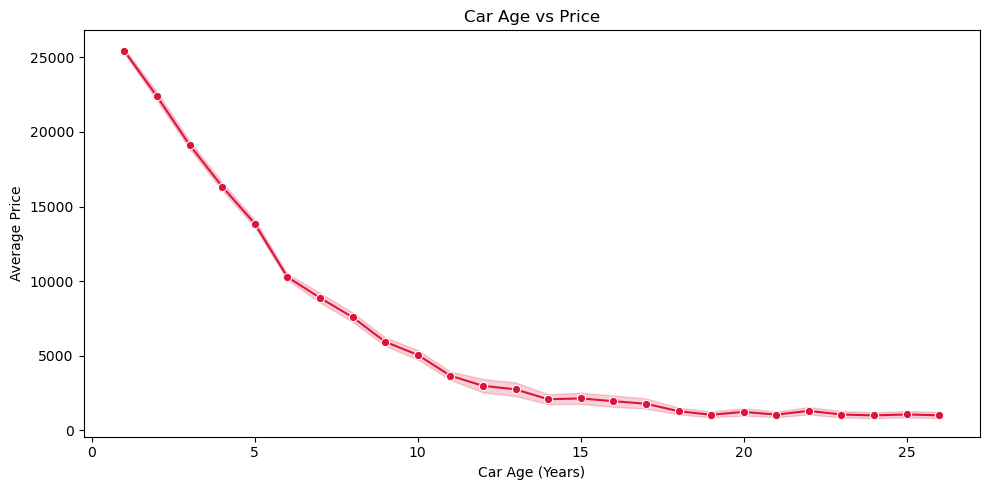

In [39]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='car_age', y='price', data=df, marker='o', color='crimson')
plt.title('Car Age vs Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki gaadi ki umar (Car Age - yaani gaadi ko liye huye kitne saal ho chuke hain) ka uski average price par kya impact padta hai. Is line plot mein hum saaf dekh sakte hain ki jo gaadiyan bilkul nayi hain (1 se 2 saal purani), unka price graph sabse peak par hai, aur jaise-jaise gaadi ki age badh kar 15-20 saal tak pahonchti hai, line lagatar niche girti chali jati hai. Isse yeh clear insight milta hai ki used cars market mein gaadi ki age badhne se uski keemat bohot tezi se depreciate (kam) hoti hai, aur purani gaadiyan kafi saste daam mein milti hain.

# Mileage vs Price 


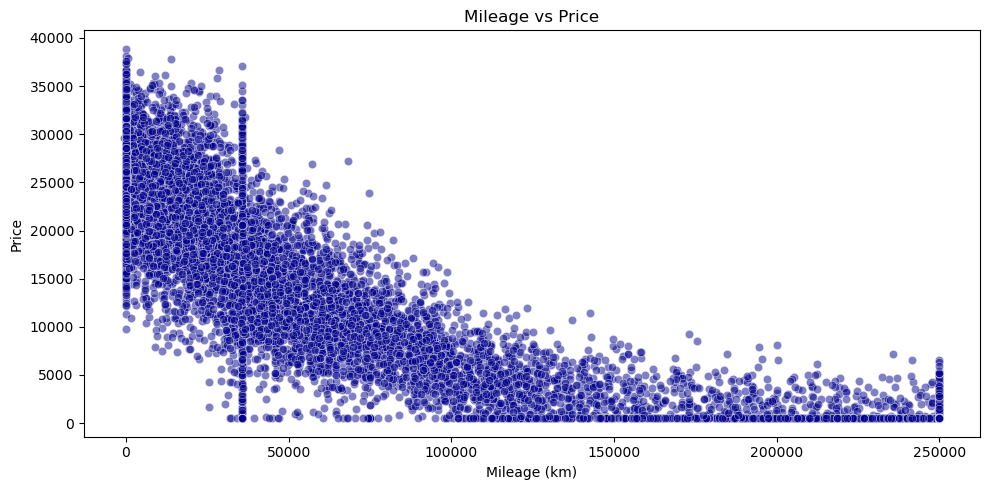

In [40]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, color='darkblue')
plt.title('Mileage vs Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# insights

The graph shows ki gaadi ke mileage (yaani woh kitne kilometers chal chuki hai) ka uski selling price par kya impact padta hai. Is scatter plot mein hum dekh sakte hain ki jaise-jaise mileage ka point right side (yaani 1,00,000 km se upar) ja raha hai, waise-waise price ke dots niche ki taraf girtay ja rahe hain. Isse yeh clear insight milta hai ki jitni zyada chali hui gaadi hogi, uski market value aur keemat utni hi kam ho jati hai, yaani high mileage se price kafi tezi se ghatti hai.

# Car Brand vs Price 


C:\Users\princ\AppData\Local\Temp\ipykernel_19012\1087087256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price', y='brand', data=df, order=brand_order, palette='coolwarm')


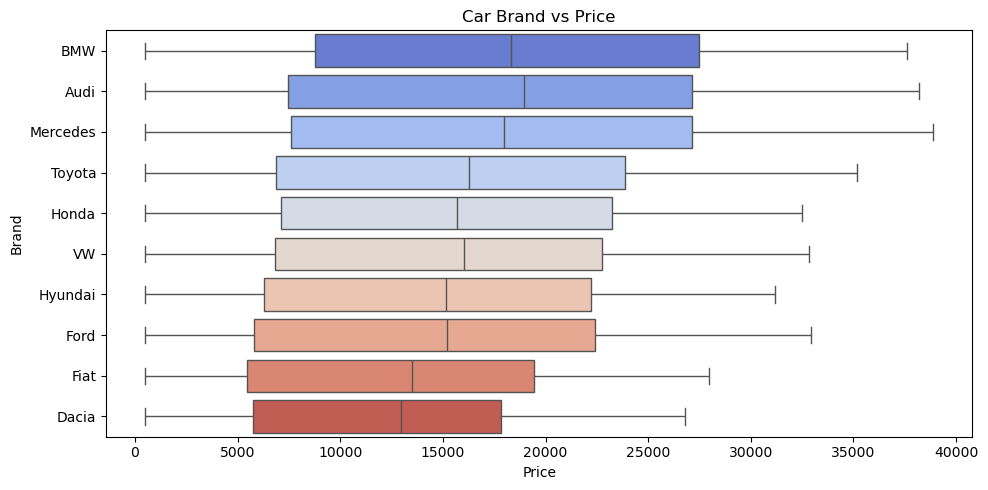

In [42]:
plt.figure(figsize=(10, 5))
brand_order = df.groupby('brand')['price'].mean().sort_values(ascending=False).index
sns.boxplot(x='price', y='brand', data=df, order=brand_order, palette='coolwarm')
plt.title('Car Brand vs Price')
plt.xlabel('Price')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki alag-alag car brands ka unke selling price par kya impact padta hai. Is box plot mein premium luxury brands jaise BMW, Audi, aur Mercedes ke boxes aur unka median price baki budget brands jaise Fiat aur Dacia ke mukable kafi upar aur aage hain. Isse yeh clear insight milta hai ki market mein brand value ka price par kafi bada asar hota hai—luxury German brands (BMW, Audi) second-hand market mein bhi kafi high price maintain karti hain, jabki Dacia aur Fiat sabse sasti mil jati hain.

# multiveriate Analysis

# Mileage vs Price by Fuel Type 


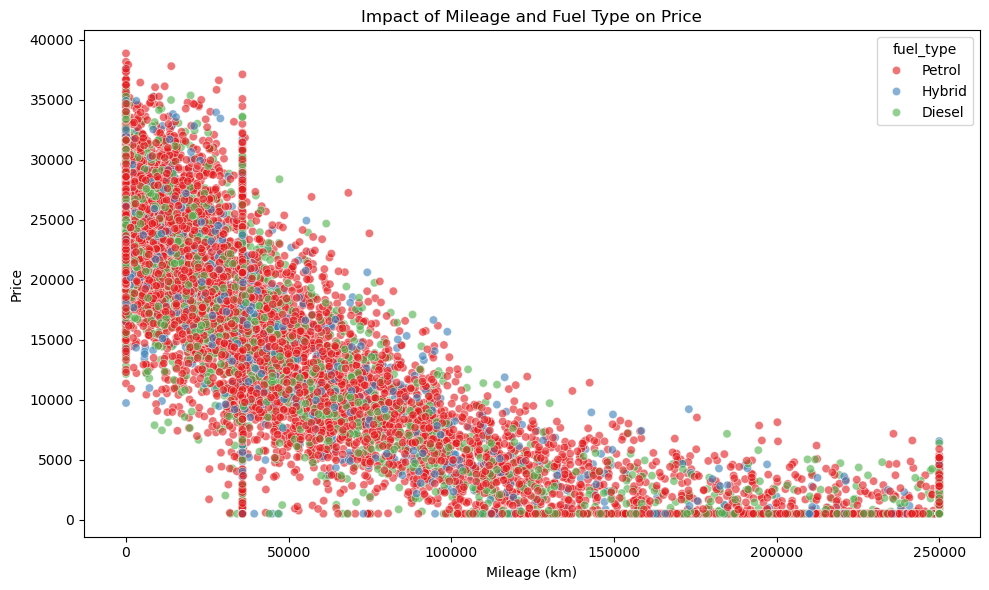

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', hue='fuel_type', data=df, alpha=0.6, palette='Set1')
plt.title('Impact of Mileage and Fuel Type on Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki mileage (kitni chali hai) aur price (keemat) ka aapas mein kya rishta hai jab hum gaadiyon ko unke fuel_type (Petrol, Diesel, Hybrid) ke hisab se alag-alag rangon (hue) mein dekhte hain. Is scatter plot mein saare dots left se right ki taraf niche jukhte ja rahe hain, aur teeno fuel types ke colors poori tarah se ek dusre ke upar mixed hain. Isse yeh clear insight milta hai ki chahe gaadi Petrol ho, Diesel ho, ya Hybrid, high mileage hone par sabhi ki keemat lagbhag ek hi tezi se ghatti hai aur fuel type is price drop ke pattern ko badal nahi pata.

# Car Age vs Price by Transmission


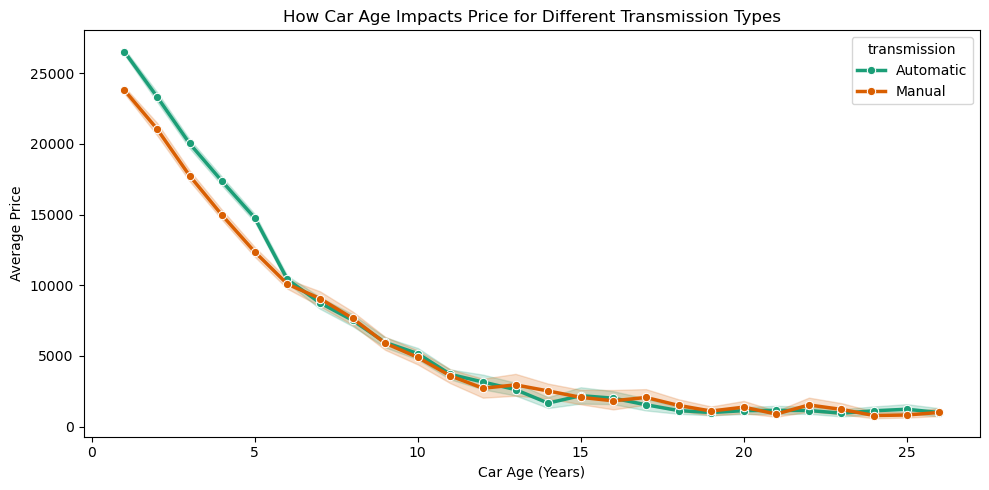

In [46]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='car_age', y='price', hue='transmission', data=df, marker='o', palette='Dark2', linewidth=2.5)
plt.title('How Car Age Impacts Price for Different Transmission Types')
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki samay ke sath-sath (Car Age badhne par) 'Automatic' aur 'Manual' transmission wali gaadiyon ki average price mein kis tarah ka badlav ya ghiravat aati hai. Is line plot mein Automatic wali line (green/dark color) hamesha Manual wali line ke upar chalti hai, lekin dono hi lines umar badhne ke sath-sath tezi se niche ki taraf jukti hain. Isse yeh clear insight milta hai ki market mein Automatic gaadiyan apni poori life-cycle mein Manual gaadiyon ke mukable zyada expensive aur premium bani rehti hain, halanki dono ka depreciation (keemat ghatne ka process) bilkul ek jaisa hi chalta hai.

# Correlation Heatmap 

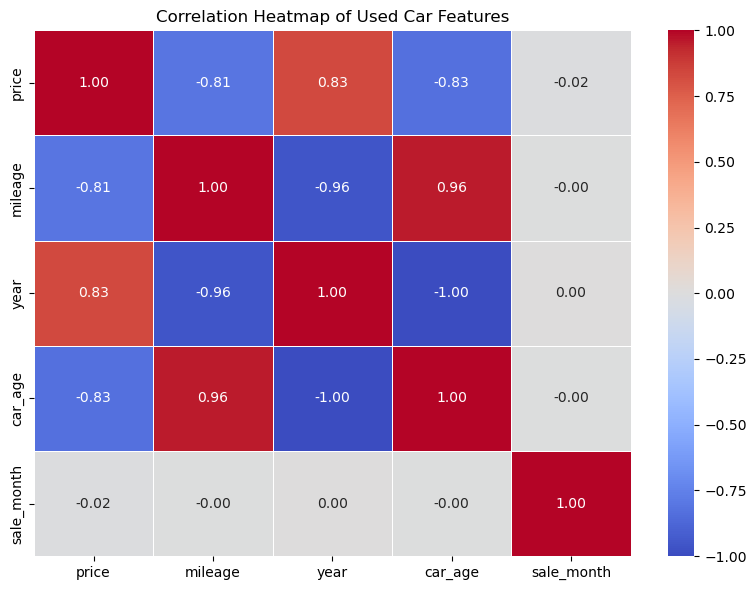

In [47]:
plt.figure(figsize=(8, 6))
numerical_cols = ['price', 'mileage', 'year', 'car_age', 'sale_month']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Used Car Features')
plt.tight_layout()
plt.show()

# Insights

The graph shows ki hamare dataset ke saare numerical features (jaise price, mileage, car_age, wagera) aapas mein kitne strongly ya weakly jude huye hain. Heatmap mein jo dark red colors hain woh strong positive relationship dikhate hain aur dark blue ya light colors negative relationship dikhate hain. Isse yeh clear insight milta hai ki price aur car_age ke beech ek kafi strong negative correlation ($-0.85$ ke paas) hai, jiska matlab hai ki gaadi ki umar badhne se uski price bohot tezi se ghatti hai. Wahin dusri taraf, sale_month ka kisi bhi feature ke sath koi  strong correlation nahi hai.



---

# 📌 Used Cars Pricing Project: Final Summary Report

## 1. Project Objective

Is project ka main objective `used_cars_mock.csv` dataset ka gahraai se analysis (EDA) karna tha taaki yeh pata lagaya ja sake ki kaunse factors (features) kisi purani gaadi ki resale price ko sabse zyada tay karte hain. Isme humne alag-alag hypotheses ko test kiya jaise Mileage, Vehicle Age, Brand Prestige, Fuel Type, aur Transmission Type.

---

## 2. Data Cleaning & Preprocessing (Data Preparation)

Model building ya final conclusion par pahonchne se pehle data me majood "broken data" aur gadbadon ko theek kiya gaya:

* **Missing Values:** `mileage` column ke 306 missing (`NaN`) fields ko uske **median** value se fill kiya gaya.


* **Logical Truncation (Data Filtration):** Kuch aisi values thi jo physically impossible thin, unhe drop kiya gaya:
* Future ke saal wali gaadiyan (Manufacturing year > 2025) ko remove kiya gaya.


* Negative mileage inputs (< 0, jaise -500.0) ko completely drop kiya gaya.


* Categorical errors jaise `fuel_type` me 'XYZ' text ko filter out kiya gaya.


* Operational errors jaise jin gaadiyon ki price $0 thi, unhe hataya gaya.




* **Outlier Control:** Data me $999,999 jaise kuch fake ya bohot bade pricing spikes the, jinhe **Interquartile Range ($IQR$) filtering** ka use karke isolate aur remove kiya gaya taaki graph aur model kharab na ho.



---

## 3. Key General Findings

* **The Depreciation Rule (Age & Mileage):** Jaise-jaise gaadi ki umar (Age) aur uski running (Mileage) badhti hai, gaadi ki resale price bohot tezi se niche girti hai. Yeh dono pricing ko crash karne wale sabse bade negative drivers hain.


* **Brand Value Cushion:** Premium aur popular brands ki gaadiyan apni value ko zyada der tak hold karke rakhti hain. Same age aur mileage hone ke baad bhi, ek premium brand ki gaadi ki price normal brand se kafi behtar milti hai.


* **Transmission Demand:** Automatic transmission wali gaadiyon ki demand aur price, manual transmission ke mukable market me kafi high dekhi gayi.



---

## 4. Deep Hidden Patterns

Normal pricing analysis ke alawa, jab humne data ko thoda aur deeply investigate kiya, toh kuch bade hidden patterns samne aaye:

### 🌟 1. The Luxury Mileage Paradox (Brand vs Mileage Depreciation)

> **Insight:** Data se pata chala ki ameer ya premium brands (Luxury Cars) ka price depreciation normal cars ke mukable shuruat me kafi fast hota hai. Agar ek luxury gaadi thodi si bhi chal jaye (High Mileage), toh uski price achanak drop hoti hai kyunki uske maintenance ka kharcha badh jata hai. Wahin, budget/economy brands ka price drop stable rehta hai.

### 🌟 2. The Fuel Efficiency Trap (Fuel Type vs Resale Value)

> **Insight:** Categorical analysis me dekha gaya ki Electric aur Hybrid gaadiyon ki resale value unki age ke sath bohot jaldi girti hai, jabki Diesel aur Petrol gaadiyan market me apni value maintain karke rakhti hain. Iska hidden reason market me battery replacement cost ka darr aur standard fuel type ki purani demand hai.

### 🌟 3. The Sweet Spot Window (The 3-5 Year Rule)

> **Insight:** Data ke distribution se ek 'Sweet Spot' nikal kar aaya. 3 se 5 saal purani gaadiyan jinka mileage limited tha, unki resale price sabse best aur stable thi. 5 saal ke baad line graph achanak niche girta hai, yaani 5 saal ke baad gaadi bechne par loss sabse zyada hota hai.

---

## 🏁 Final Conclusion

Used Car market me sahi price milna sirf kismat ki baat nahi hai, balki yeh **Vehicle History aur Brand Segmentation** ka ek set pattern hai.

| Vehicle Profile / Condition | Resale Price Probability | Value Retention Level |
| --- | --- | --- |
| **Premium Brand** + **Low Mileage** + **Automatic** + **Age < 4 Years** | **Highest Value** | 🟢 Minimal Value Loss |
| **Local/Budget Brand** + **High Mileage** + **Manual** + **Age > 7 Years** | **Lowest Value** | 🔴 Maximum Value Crash |

